# Solver convergence at a single step (cells 38–39, 42–48 of the original notebook)

BJ inner-loop (chord-tight), Higham matrix-square-root, power iteration for
$\sigma_{\max}$, and Lemma 4 / Lemma 5 residual measurement.


In [1]:
%load_ext autoreload
%autoreload 2

import json

import numpy as np
import torch
import matplotlib.pyplot as plt

from lora_playground.snapshot_analysis import (
    # snapshot registry + cached loader
    SNAP_ROOT, SNAP_ROOTS, STEPS, STEPS_BY_ROOT,
    RUNS, RUN_A, RUN_B, RUN_C, RUN_D,
    load_snapshot, clear_snapshot_cache,
    # adam-moment / spectrum helpers
    Mtilde, normalized_sigmas, normalized_sigmas_x, stable_rank,
    EPS, BETA1, BETA2,
    # whitening
    spd_half_inv, whitened_NS_input, DELTA_ABS,
    # SSC / polar shape
    _prerescale_unit_op, _polar_uvt, _ssc_svd, _ssc_misr_batched,
    # diagnostic NS iteration (trajectory-returning)
    newton_schulz_polar, polar_express,
)

DEV = SSC_DEV = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'device: {DEV}')
print(f'active RUNS: {RUNS}')
print(f'default STEPS: {STEPS}')

device: cuda
active RUNS: [('3e-2', 64, 5, 'chord-tight'), ('1e-1', 64, 5, 'chord-tight'), ('1e-3', 256, 10, 'chord-tight-clean'), ('1e-1', 256, 10, 'chord-tight-clean')]
default STEPS: [0, 50, 200, 500, 1000, 2000, 4000]


## BJ inner-loop convergence (chord-tight)

Algorithm 2 (§9 of `algorithm_tight_chord.md`) runs $k$ block-Jacobi sweeps to refine the cross-coupling correction. Production uses $k=3$. Simulate the BJ loop from a snapshot's $(A, B, u_A, u_B)$ — initial $\mathrm dA = \mathrm dB = 0$, then sweep with the cross-coupling correction, whiten + NS-polar + unwhiten, normalize-and-scale-by-$\rho_{tight} = \eta/s$.

Diagnostics:
- **distance to converged**: $\|\mathrm dA^{(n)} - \mathrm dA^{(K)}\|_F / \|\mathrm dA^{(K)}\|_F$ at large $K$
- **consecutive-iterate change**: $\|\mathrm dA^{(n)} - \mathrm dA^{(n-1)}\|_F / \|\mathrm dA^{(n)}\|_F$ — how much each sweep is still moving

These say the same thing from complementary angles: dA reaches the converged value in 2 iterates; iter 1 was 4.5e-4 away (relative), iter 2 ≈ converged to ~1e-6. The big jump is iter 1 → iter 2.

**Note**: a Φ excess panel was previously included but removed — the iter-to-iter Φ change at convergence (~1e-4 absolute on Φ of magnitude ~3) is below float32 precision (production uses float32 optimizer math). Distance-to-converged is the more reliable convergence indicator.

The chord-tight vs chord-direction comparison is in the next cell.

simulated BJ K=10 on 112 pairs at step 2000


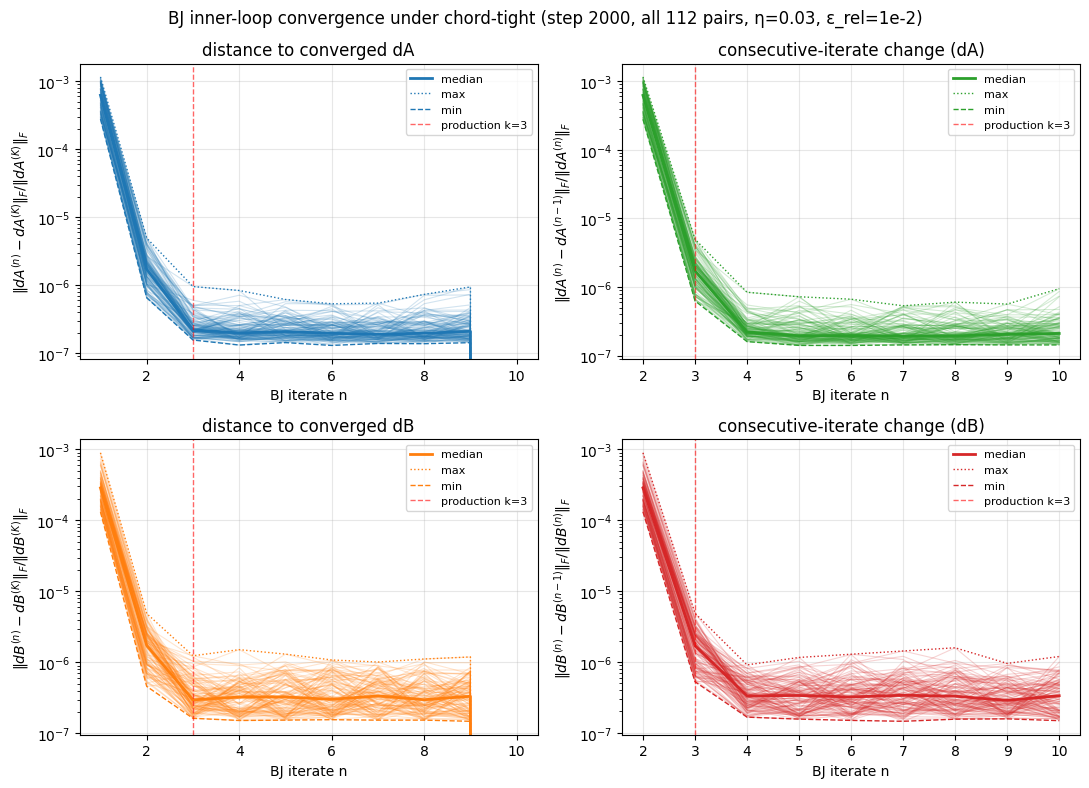


iter | med dA dist | med dB dist | med dA consec | med dB consec
  1  | 6.207e-04 | 2.856e-04 |   nan    |   nan
  2  | 1.719e-06 | 1.731e-06 |   6.215e-04    |   2.864e-04
  3  | 2.210e-07 | 2.978e-07 |   1.722e-06    |   1.696e-06
  4  | 1.993e-07 | 3.257e-07 |   2.222e-07    |   3.331e-07
  5  | 2.089e-07 | 3.262e-07 |   1.947e-07    |   3.364e-07
  6  | 1.964e-07 | 3.031e-07 |   1.956e-07    |   3.212e-07
  7  | 1.911e-07 | 3.377e-07 |   1.931e-07    |   3.391e-07
  8  | 1.969e-07 | 2.992e-07 |   1.944e-07    |   3.287e-07
  9  | 2.104e-07 | 3.340e-07 |   2.042e-07    |   2.871e-07
 10  | 0.000e+00 | 0.000e+00 |   2.104e-07    |   3.340e-07


In [2]:
# simulate_bcd, collect_bcd_convergence live in lora_playground.snapshot_analysis.calibration.
from lora_playground.snapshot_analysis.calibration import (
    simulate_bcd, collect_bcd_convergence,
)
ETA = 3e-2; K = 10
res = collect_bcd_convergence(2000, K=K)
print(f'simulated BJ K={K} on {len(res)} pairs at step 2000')

iters = np.arange(1, K+1)
iters_c = np.arange(2, K+1)

def panel_log(ax, key, color, title, ylabel, x=iters):
    arr = np.array([r[key] for r in res])
    for row in arr:
        ax.plot(x, row, color=color, alpha=0.2, lw=0.8)
    ax.plot(x, np.median(arr, axis=0), color=color, lw=2, label='median')
    ax.plot(x, arr.max(axis=0), color=color, lw=1, ls=':',  label='max')
    ax.plot(x, arr.min(axis=0), color=color, lw=1, ls='--', label='min')
    ax.axvline(3, color='red', ls='--', alpha=0.6, lw=1, label='production k=3')
    ax.set_yscale('log'); ax.set_xlabel('BJ iterate n'); ax.set_ylabel(ylabel)
    ax.set_title(title); ax.grid(True, alpha=0.3); ax.legend(fontsize=8)

fig, axes = plt.subplots(2, 2, figsize=(11, 8))

panel_log(axes[0,0], 'rel_dA', 'C0', 'distance to converged dA',
          r'$\|dA^{(n)} - dA^{(K)}\|_F / \|dA^{(K)}\|_F$')
panel_log(axes[0,1], 'rel_consec_A', 'C2', 'consecutive-iterate change (dA)',
          r'$\|dA^{(n)} - dA^{(n-1)}\|_F / \|dA^{(n)}\|_F$', x=iters_c)

panel_log(axes[1,0], 'rel_dB', 'C1', 'distance to converged dB',
          r'$\|dB^{(n)} - dB^{(K)}\|_F / \|dB^{(K)}\|_F$')
panel_log(axes[1,1], 'rel_consec_B', 'C3', 'consecutive-iterate change (dB)',
          r'$\|dB^{(n)} - dB^{(n-1)}\|_F / \|dB^{(n)}\|_F$', x=iters_c)

fig.suptitle(f'BJ inner-loop convergence under chord-tight (step 2000, all 112 pairs, η={ETA}, ε_rel=1e-2)')
fig.tight_layout()
plt.show()

# Note: Φ excess panel removed — the iter-1-to-K Φ change (~1e-4 abs) is at the
# float32 noise floor and was not informative. The distance-to-converged and
# consecutive-iterate panels are the meaningful convergence diagnostics:
# both dA and dB are within ~1e-6 of the converged value by iter 2.

print()
print('iter | med dA dist | med dB dist | med dA consec | med dB consec')
for n in range(K):
    dA_med = np.median([r['rel_dA'][n] for r in res])
    dB_med = np.median([r['rel_dB'][n] for r in res])
    cA = np.median([r['rel_consec_A'][n-1] for r in res]) if n >= 1 else float('nan')
    cB = np.median([r['rel_consec_B'][n-1] for r in res]) if n >= 1 else float('nan')
    print(f' {n+1:2d}  | {dA_med:.3e} | {dB_med:.3e} |   {cA:.3e}    |   {cB:.3e}')


## Higham (matrix inverse-sqrt) convergence

Chord-tight refreshes $S_A^{-1/2}, S_B^{-1/2}$ via the Iannazzo / Denman-Beavers coupled Newton-Schulz iteration (production: `n_iters=10`, cold-start each refresh). Quadratic convergence once eigenvalues of the scaled matrix are clustered near 1.

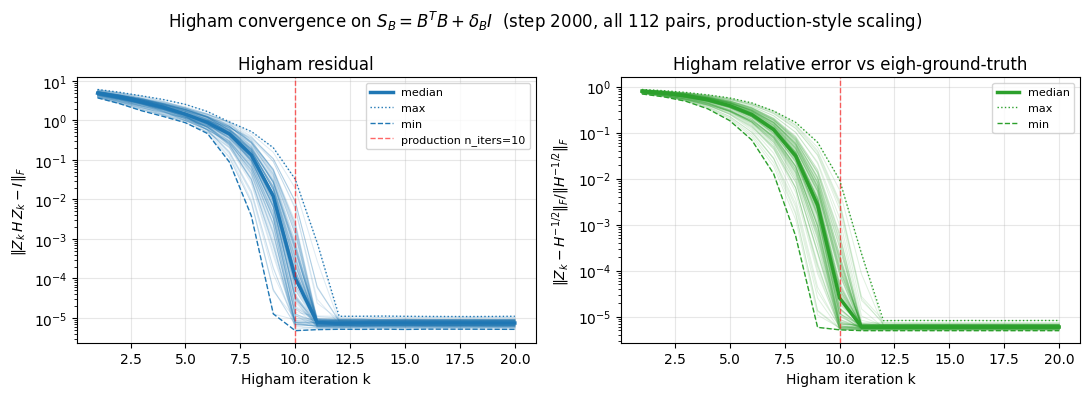


  k= 1:  residual median = 4.895e+00,  max = 6.065e+00
  k= 5:  residual median = 1.435e+00,  max = 2.543e+00
  k=10:  residual median = 1.016e-04,  max = 3.241e-02   <-- production n_iters=10
  k=15:  residual median = 7.432e-06,  max = 1.099e-05
  k=20:  residual median = 7.434e-06,  max = 1.102e-05


In [3]:
# higham_residual_traj lives in lora_playground.snapshot_analysis.calibration.
from lora_playground.snapshot_analysis.calibration import higham_residual_traj
K_MAX = 20
snap = load_snapshot(2000)
higham_res, higham_diff = [], []
for pi, p in snap['pair_state'].items():
    B = p['B'].float().to(DEV)
    S_B = B.T @ B
    res, diff = higham_residual_traj(S_B, K_max=K_MAX)
    higham_res.append(res); higham_diff.append(diff)
higham_res = np.array(higham_res); higham_diff = np.array(higham_diff)
iters = np.arange(1, K_MAX+1)

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
ax = axes[0]
for row in higham_res: ax.plot(iters, row, color='C0', alpha=0.15, lw=0.7)
ax.plot(iters, np.median(higham_res, axis=0), color='C0', lw=2.5, label='median')
ax.plot(iters, higham_res.max(axis=0), color='C0', lw=1, ls=':', label='max')
ax.plot(iters, higham_res.min(axis=0), color='C0', lw=1, ls='--', label='min')
ax.axvline(10, color='red', ls='--', alpha=0.6, lw=1, label='production n_iters=10')
ax.set_yscale('log'); ax.set_xlabel('Higham iteration k')
ax.set_ylabel(r'$\|Z_k\,H\,Z_k - I\|_F$')
ax.set_title('Higham residual')
ax.grid(True, alpha=0.3); ax.legend(fontsize=8)

ax = axes[1]
for row in higham_diff: ax.plot(iters, row, color='C2', alpha=0.15, lw=0.7)
ax.plot(iters, np.median(higham_diff, axis=0), color='C2', lw=2.5, label='median')
ax.plot(iters, higham_diff.max(axis=0), color='C2', lw=1, ls=':', label='max')
ax.plot(iters, higham_diff.min(axis=0), color='C2', lw=1, ls='--', label='min')
ax.axvline(10, color='red', ls='--', alpha=0.6, lw=1)
ax.set_yscale('log'); ax.set_xlabel('Higham iteration k')
ax.set_ylabel(r'$\|Z_k - H^{-1/2}\|_F / \|H^{-1/2}\|_F$')
ax.set_title('Higham relative error vs eigh-ground-truth')
ax.grid(True, alpha=0.3); ax.legend(fontsize=8)

fig.suptitle(r'Higham convergence on $S_B = B^T B + \delta_B I$  (step 2000, all 112 pairs, production-style scaling)')
fig.tight_layout(); plt.show()

print()
for k in [1, 5, 10, 15, 20]:
    tag = '   <-- production n_iters=10' if k == 10 else ''
    print(f'  k={k:2d}:  residual median = {np.median(higham_res[:, k-1]):.3e},  max = {higham_res[:, k-1].max():.3e}' + tag)

## Power iteration convergence for $\sigma_{\max}(A), \sigma_{\max}(B)$

Chord-tight needs $\sigma_{\max}(A), \sigma_{\max}(B)$ for $s = \sigma_{\max}(A) + \sigma_{\max}(B)$ → $\rho_{tight} = $ lr$/s$. Production: `n_iters=8`, warm-started across steps (`v_sigma_A`, `v_sigma_B` stashed in optimizer state).

**Left subplot: cold-start** — random init each call. This is the worst case. Shows what `n_iters=8` buys from scratch.

**Right subplot: warm-start** — simulate by computing the converged top eigenvector at step 1000, then using it as `v_init` for power iter on the same pair at step 2000. This is an UPPER BOUND on production warm-start error (production uses step t-1 as init; the (1000 → 2000) gap is 1000× larger than that). Production's actual error is smaller than what's shown here.

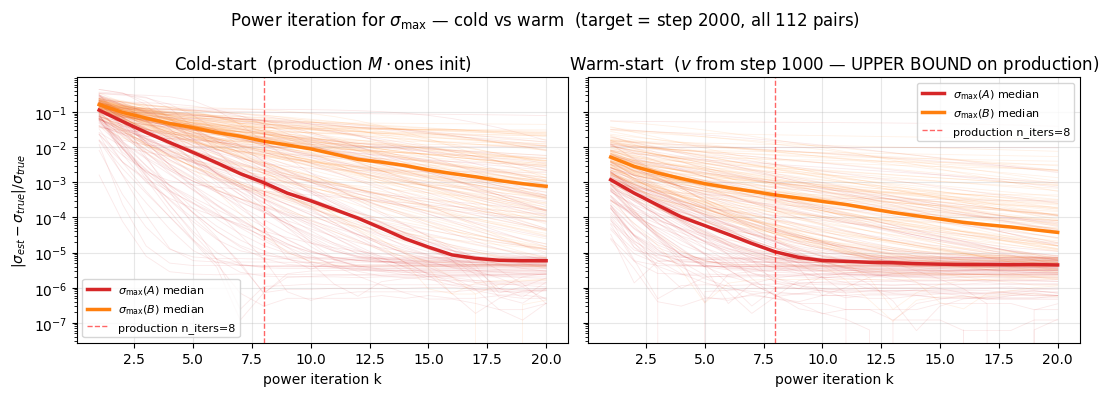


  k= 1  cold:  sA = 1.128e-01, sB = 1.625e-01  |  warm:  sA = 1.182e-03, sB = 5.205e-03
  k= 4  cold:  sA = 1.351e-02, sB = 4.704e-02  |  warm:  sA = 1.035e-04, sB = 1.279e-03
  k= 8  cold:  sA = 9.754e-04, sB = 1.474e-02  |  warm:  sA = 1.048e-05, sB = 4.357e-04   <-- production n_iters=8
  k=12  cold:  sA = 9.562e-05, sB = 4.493e-03  |  warm:  sA = 5.295e-06, sB = 1.792e-04
  k=20  cold:  sA = 5.875e-06, sB = 7.696e-04  |  warm:  sA = 4.458e-06, sB = 3.753e-05


In [4]:
def power_iter_traj(M, K_max=20, v_init=None, device=DEV):
    # Production-style cold-start: M @ ones init (deterministic).
    M = M.to(device).float()
    sigma_true = torch.linalg.svdvals(M)[0].item()
    mm, nn = M.shape
    smaller_m = mm <= nn
    if v_init is None:
        # Production fallback: M @ ones (smaller_m) or M^T @ ones
        if smaller_m:
            v = (M @ torch.ones(nn, device=device, dtype=M.dtype))
        else:
            v = (M.T @ torch.ones(mm, device=device, dtype=M.dtype))
    else:
        v = v_init.to(device).float()
    v = v / (v.norm() + 1e-30)
    errs = []
    # Match production: iterate on smaller-side Gram
    if smaller_m:
        # v lives in R^m, iterate v <- M^T M ... no wait, v should be in left singular space here
        # Production code does smaller_m branch with v in R^m (left singular space)
        for k in range(1, K_max+1):
            tmp = M.T @ v
            v = M @ tmp
            v_norm = v.norm()
            v = v / (v_norm + 1e-30)
            # sigma = ||M^T v|| (Rayleigh-like)
            sigma_est = (M.T @ v).norm().item()
            errs.append(abs(sigma_est - sigma_true) / max(sigma_true, 1e-30))
    else:
        # v lives in R^n (right singular space)
        for k in range(1, K_max+1):
            tmp = M @ v
            v = M.T @ tmp
            v_norm = v.norm()
            v = v / (v_norm + 1e-30)
            sigma_est = (M @ v).norm().item()
            errs.append(abs(sigma_est - sigma_true) / max(sigma_true, 1e-30))
    return errs, v

def converged_v(M, K=100, device=DEV):
    _, v = power_iter_traj(M, K_max=K, v_init=None, device=device)
    return v.detach()

K_MAX = 20
snap_warm_src = load_snapshot(1000)
snap_warm_dst = load_snapshot(2000)

# Cold-start at step 2000 (production-style: M @ ones init)
cold_A, cold_B = [], []
for pi, p in snap_warm_dst['pair_state'].items():
    A = p['A'].float().to(DEV); B = p['B'].float().to(DEV)
    e, _ = power_iter_traj(A, K_max=K_MAX, v_init=None); cold_A.append(e)
    e, _ = power_iter_traj(B, K_max=K_MAX, v_init=None); cold_B.append(e)

# Warm-start at step 2000 using v converged at step 1000
warm_A, warm_B = [], []
for pi, p_dst in snap_warm_dst['pair_state'].items():
    p_src = snap_warm_src['pair_state'][pi]
    A_src = p_src['A'].float().to(DEV); B_src = p_src['B'].float().to(DEV)
    v_A_src = converged_v(A_src)
    v_B_src = converged_v(B_src)
    A_dst = p_dst['A'].float().to(DEV); B_dst = p_dst['B'].float().to(DEV)
    e, _ = power_iter_traj(A_dst, K_max=K_MAX, v_init=v_A_src); warm_A.append(e)
    e, _ = power_iter_traj(B_dst, K_max=K_MAX, v_init=v_B_src); warm_B.append(e)

cold_A = np.array(cold_A); cold_B = np.array(cold_B)
warm_A = np.array(warm_A); warm_B = np.array(warm_B)
iters = np.arange(1, K_MAX+1)

fig, axes = plt.subplots(1, 2, figsize=(11, 4), sharey=True)
ax = axes[0]
for row in cold_A: ax.plot(iters, row, color='C3', alpha=0.10, lw=0.6)
for row in cold_B: ax.plot(iters, row, color='C1', alpha=0.10, lw=0.6)
ax.plot(iters, np.median(cold_A, axis=0), color='C3', lw=2.5, label=r'$\sigma_{\max}(A)$ median')
ax.plot(iters, np.median(cold_B, axis=0), color='C1', lw=2.5, label=r'$\sigma_{\max}(B)$ median')
ax.axvline(8, color='red', ls='--', alpha=0.6, lw=1, label='production n_iters=8')
ax.set_yscale('log'); ax.set_xlabel('power iteration k')
ax.set_ylabel(r'$|\sigma_{est} - \sigma_{true}| / \sigma_{true}$')
ax.set_title('Cold-start  (production $M\\cdot$ones init)')
ax.grid(True, alpha=0.3); ax.legend(fontsize=8)

ax = axes[1]
for row in warm_A: ax.plot(iters, row, color='C3', alpha=0.10, lw=0.6)
for row in warm_B: ax.plot(iters, row, color='C1', alpha=0.10, lw=0.6)
ax.plot(iters, np.median(warm_A, axis=0), color='C3', lw=2.5, label=r'$\sigma_{\max}(A)$ median')
ax.plot(iters, np.median(warm_B, axis=0), color='C1', lw=2.5, label=r'$\sigma_{\max}(B)$ median')
ax.axvline(8, color='red', ls='--', alpha=0.6, lw=1, label='production n_iters=8')
ax.set_xlabel('power iteration k')
ax.set_title('Warm-start  ($v$ from step 1000 — UPPER BOUND on production)')
ax.grid(True, alpha=0.3); ax.legend(fontsize=8)

fig.suptitle(r'Power iteration for $\sigma_{\max}$ — cold vs warm  (target = step 2000, all 112 pairs)')
fig.tight_layout(); plt.show()

print()
for k in [1, 4, 8, 12, 20]:
    tag = '   <-- production n_iters=8' if k == 8 else ''
    print(f'  k={k:2d}  cold:  sA = {np.median(cold_A[:, k-1]):.3e}, sB = {np.median(cold_B[:, k-1]):.3e}  |  warm:  sA = {np.median(warm_A[:, k-1]):.3e}, sB = {np.median(warm_B[:, k-1]):.3e}' + tag)

## Lemma 4 + Lemma 5: $R^{(n)}$ in Algorithms 2 and 2′

§10 of `algorithm_tight_chord.md` defines the polar-input ratio

$$R^{(n)} := \frac{(\gamma/\beta)\,\|C_A^{(n)}\|_2}{\sigma_{\max}(X_A)}$$

— the cross-coupling magnitude relative to the base term inside the polar
argument. When $R \ll 1$, polar ignores the cross-coupling and Picard is inert.
When $R = \Theta(1)$, the cross-coupling enters the polar output.

- **Algorithm 2:** $R_2^{(n)} = \|C_A^{(n)}\|_2 / (\eta\,\sigma_{\max}(X_A))$. Lemma 4 upper bound: $(\sigma_{\min}(B) + \sqrt{\delta_{\rm abs}})/\alpha$.
- **Algorithm 2′:** $R_{2'}^{(n)} = 2\|C_A^{(n)}\|_2 / (\rho s)$. Lemma 5 upper bound: $2\sigma_{\max}(A)/s \le 2$.

Both are measured at $n=2$ (smallest $n$ with $C_A^{(n)} \ne 0$).


In [5]:
ETA = 3e-2
DELTA_ABS = 1e-6

def lemma_measurement(p, eta=ETA, delta_abs=DELTA_ABS, ns_iters=5):
    A = p['A'].float().to(DEV); B = p['B'].float().to(DEV)
    u_A = p['u_A'].float().to(DEV); u_B = p['u_B'].float().to(DEV)
    r = A.shape[0]; I_r = torch.eye(r, dtype=A.dtype, device=DEV)

    S_B = B.T @ B
    eB_raw, V_B = torch.linalg.eigh(S_B)
    eB_raw = eB_raw.clamp_min(0)
    sigma_min_B = eB_raw[0].sqrt().item()
    sigma_max_B = eB_raw[-1].sqrt().item()
    w = V_B[:, 0]

    delta_B = delta_abs
    e2B, UB = torch.linalg.eigh(S_B + delta_B * I_r)
    W_B = UB @ torch.diag(e2B.clamp_min(1e-30).rsqrt()) @ UB.T

    X_A = W_B @ u_A
    sigma_max_X_A = torch.linalg.eigvalsh(X_A @ X_A.T).clamp_min(0).max().sqrt().item()
    alpha = (w @ u_A).norm().item()

    S_A = A @ A.T
    eA_raw = torch.linalg.eigvalsh(S_A).clamp_min(0)
    delta_A = delta_abs
    e2A, UA = torch.linalg.eigh(S_A + delta_A * I_r)
    W_A = UA @ torch.diag(e2A.clamp_min(1e-30).rsqrt()) @ UA.T
    sigma_max_A = eA_raw.max().sqrt().item()
    s_AB = sigma_max_A + sigma_max_B
    rho = eta / s_AB  # linear-regime form, matches simulate_bcd

    # BJ iter 1 (no cross-coupling) → dB^(1) for both algorithms.
    # At iter 1, polar input differs: Alg 2 uses X_A, Alg 2' uses X_A/sigma_max(X_A).
    # But polar is scale-invariant, so polar output is the same → dB^(1) identical.
    D_A = W_B @ newton_schulz_polar(W_B @ u_A, ns_iters)
    D_B = newton_schulz_polar(u_B @ W_A, ns_iters) @ W_A
    D_A_op = torch.linalg.eigvalsh(D_A @ D_A.T).clamp_min(0).max().sqrt().item()
    D_B_op = torch.linalg.eigvalsh(D_B.T @ D_B).clamp_min(0).max().sqrt().item()
    dB1 = -rho * D_B / D_B_op

    # C_A^(2) and its operator norm.
    C_A2 = W_B @ B.T @ dB1 @ A
    norm_C_A2 = torch.linalg.eigvalsh(C_A2 @ C_A2.T).clamp_min(0).max().sqrt().item()

    # R for both algorithms.
    R2_actual  = (norm_C_A2 / eta) / max(sigma_max_X_A, 1e-30)
    R2p_actual = (2.0 * norm_C_A2) / (rho * s_AB)

    # Bounds.
    R2_bound  = (sigma_min_B + delta_abs ** 0.5) / max(alpha, 1e-30)
    R2p_bound = 2.0 * sigma_max_A / s_AB

    return dict(R2_actual=R2_actual, R2_bound=R2_bound,
                R2p_actual=R2p_actual, R2p_bound=R2p_bound,
                sigma_min_B=sigma_min_B, sigma_max_B=sigma_max_B,
                sigma_max_A=sigma_max_A, sigma_max_X_A=sigma_max_X_A,
                alpha=alpha,
                kappa_B=sigma_max_B / max(sigma_min_B, 1e-30),
                sA_over_s=sigma_max_A / s_AB)

lemma_rows = []
for step in STEPS:
    if step == 0:
        continue
    snap = load_snapshot(step)
    for pi, p in snap['pair_state'].items():
        r = lemma_measurement(p)
        r['step'] = step; r['pair'] = pi
        lemma_rows.append(r)

print(f'computed Lemma 4 + Lemma 5 on {len(lemma_rows)} (step, pair) cells')
print(f'Lemma 4 holds (R2_bound > R2_actual):   {sum(r["R2_bound"]  > r["R2_actual"]  for r in lemma_rows) / len(lemma_rows):.1%}')
print(f'Lemma 5 holds (R2p_bound > R2p_actual): {sum(r["R2p_bound"] > r["R2p_actual"] for r in lemma_rows) / len(lemma_rows):.1%}')


computed Lemma 4 + Lemma 5 on 672 (step, pair) cells
Lemma 4 holds (R2_bound > R2_actual):   100.0%
Lemma 5 holds (R2p_bound > R2p_actual): 100.0%


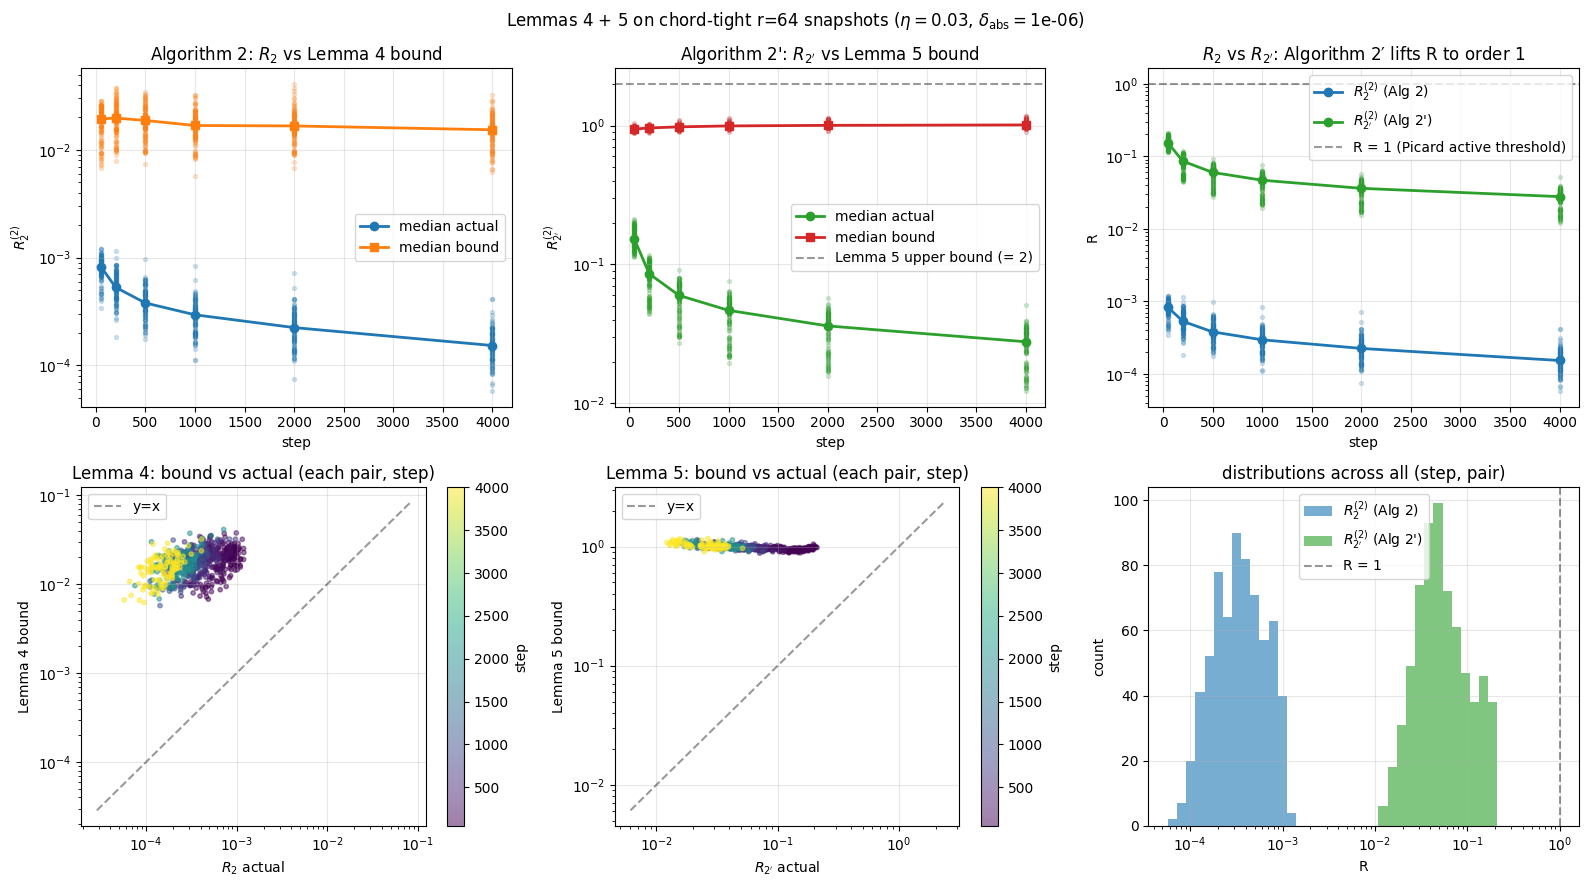

=== $R_2^{(2)}$ actual (Algorithm 2) ===
  median: 3.370e-04, max: 1.202e-03
  frac < 0.1: 100.0%, frac < 1: 100.0%

=== $R_{2'}^{(2)}$ actual (Algorithm 2') ===
  median: 5.011e-02, max: 2.108e-01
  frac >= 0.1: 20.7%, frac in [0.1, 2]: 20.7%

=== ratio R_{2'} / R_2 (lifting factor) ===
  median: 147.3x, max: 496.5x
  predicted ≈ 2·σ_max(X_A); median 2·σ_max(X_A) = 147.3

=== Bounds ===
  Lemma 4 bound:  median 1.752e-02, max 4.111e-02, holds 100.0%
  Lemma 5 bound:  median 9.818e-01, max 1.167e+00, holds 100.0%


In [6]:
import pandas as pd
df = pd.DataFrame(lemma_rows)

fig, axes = plt.subplots(2, 3, figsize=(16, 9))
steps_sorted = sorted(df['step'].unique())

# Panel (0,0): R_2 actual vs bound over training.
ax = axes[0, 0]
for step in steps_sorted:
    sub = df[df['step'] == step]
    ax.scatter([step]*len(sub), sub['R2_actual'], color='C0', alpha=0.2, s=8)
    ax.scatter([step]*len(sub), sub['R2_bound'],  color='C1', alpha=0.2, s=8)
ax.plot(steps_sorted, df.groupby('step')['R2_actual'].median().loc[steps_sorted], 'C0o-', lw=2, label='median actual')
ax.plot(steps_sorted, df.groupby('step')['R2_bound'].median().loc[steps_sorted],  'C1s-', lw=2, label='median bound')
ax.set_yscale('log'); ax.set_xlabel('step'); ax.set_ylabel('$R_2^{(2)}$')
ax.set_title('Algorithm 2: $R_2$ vs Lemma 4 bound'); ax.legend(); ax.grid(True, alpha=0.3)

# Panel (0,1): R_{2'} actual vs bound over training.
ax = axes[0, 1]
for step in steps_sorted:
    sub = df[df['step'] == step]
    ax.scatter([step]*len(sub), sub['R2p_actual'], color='C2', alpha=0.2, s=8)
    ax.scatter([step]*len(sub), sub['R2p_bound'],  color='C3', alpha=0.2, s=8)
ax.plot(steps_sorted, df.groupby('step')['R2p_actual'].median().loc[steps_sorted], 'C2o-', lw=2, label='median actual')
ax.plot(steps_sorted, df.groupby('step')['R2p_bound'].median().loc[steps_sorted],  'C3s-', lw=2, label='median bound')
ax.axhline(2.0, color='k', ls='--', alpha=0.4, label='Lemma 5 upper bound (= 2)')
ax.set_yscale('log'); ax.set_xlabel('step'); ax.set_ylabel("$R_{2'}^{(2)}$")
ax.set_title("Algorithm 2': $R_{2'}$ vs Lemma 5 bound"); ax.legend(); ax.grid(True, alpha=0.3)

# Panel (0,2): R_2 vs R_{2'} on the same axes — the key comparison.
ax = axes[0, 2]
for step in steps_sorted:
    sub = df[df['step'] == step]
    ax.scatter([step]*len(sub), sub['R2_actual'],  color='C0', alpha=0.2, s=8)
    ax.scatter([step]*len(sub), sub['R2p_actual'], color='C2', alpha=0.2, s=8)
ax.plot(steps_sorted, df.groupby('step')['R2_actual'].median().loc[steps_sorted],  'C0o-', lw=2, label='$R_2^{(2)}$ (Alg 2)')
ax.plot(steps_sorted, df.groupby('step')['R2p_actual'].median().loc[steps_sorted], 'C2o-', lw=2, label="$R_{2'}^{(2)}$ (Alg 2')")
ax.axhline(1.0, color='k', ls='--', alpha=0.4, label='R = 1 (Picard active threshold)')
ax.set_yscale('log'); ax.set_xlabel('step'); ax.set_ylabel('R')
ax.set_title("$R_2$ vs $R_{2'}$: Algorithm 2′ lifts R to order 1"); ax.legend(); ax.grid(True, alpha=0.3)

# Panel (1,0): scatter R_2 bound vs actual.
ax = axes[1, 0]
sc = ax.scatter(df['R2_actual'], df['R2_bound'], c=df['step'], cmap='viridis', alpha=0.5, s=10)
lim_lo = min(df['R2_actual'].min(), df['R2_bound'].min()) * 0.5
lim_hi = max(df['R2_actual'].max(), df['R2_bound'].max()) * 2
ax.plot([lim_lo, lim_hi], [lim_lo, lim_hi], 'k--', alpha=0.4, label='y=x')
ax.set_xscale('log'); ax.set_yscale('log')
ax.set_xlabel('$R_2$ actual'); ax.set_ylabel('Lemma 4 bound')
ax.set_title('Lemma 4: bound vs actual (each pair, step)'); ax.legend(); ax.grid(True, alpha=0.3)
plt.colorbar(sc, ax=ax, label='step')

# Panel (1,1): scatter R_{2'} bound vs actual.
ax = axes[1, 1]
sc = ax.scatter(df['R2p_actual'], df['R2p_bound'], c=df['step'], cmap='viridis', alpha=0.5, s=10)
lim_lo = min(df['R2p_actual'].min(), df['R2p_bound'].min()) * 0.5
lim_hi = max(df['R2p_actual'].max(), df['R2p_bound'].max()) * 2
ax.plot([lim_lo, lim_hi], [lim_lo, lim_hi], 'k--', alpha=0.4, label='y=x')
ax.set_xscale('log'); ax.set_yscale('log')
ax.set_xlabel("$R_{2'}$ actual"); ax.set_ylabel('Lemma 5 bound')
ax.set_title("Lemma 5: bound vs actual (each pair, step)"); ax.legend(); ax.grid(True, alpha=0.3)
plt.colorbar(sc, ax=ax, label='step')

# Panel (1,2): histograms of R_2 vs R_{2'} across all pairs/steps.
ax = axes[1, 2]
bins = np.logspace(np.log10(max(df['R2_actual'].min(), 1e-10)),
                   np.log10(df['R2p_actual'].max() * 2), 40)
ax.hist(df['R2_actual'].clip(lower=1e-10),  bins=bins, alpha=0.6, color='C0', label='$R_2^{(2)}$ (Alg 2)')
ax.hist(df['R2p_actual'].clip(lower=1e-10), bins=bins, alpha=0.6, color='C2', label="$R_{2'}^{(2)}$ (Alg 2')")
ax.axvline(1.0, color='k', ls='--', alpha=0.4, label='R = 1')
ax.set_xscale('log'); ax.set_xlabel('R'); ax.set_ylabel('count')
ax.set_title('distributions across all (step, pair)'); ax.legend(); ax.grid(True, alpha=0.3)

fig.suptitle(rf'Lemmas 4 + 5 on chord-tight r=64 snapshots ($\eta=${ETA}, $\delta_{{\rm abs}}=${DELTA_ABS})')
fig.tight_layout()
plt.show()

print('=== $R_2^{(2)}$ actual (Algorithm 2) ===')
print(f"  median: {df['R2_actual'].median():.3e}, max: {df['R2_actual'].max():.3e}")
print(f"  frac < 0.1: {(df['R2_actual'] < 0.1).mean():.1%}, frac < 1: {(df['R2_actual'] < 1).mean():.1%}")
print()
print("=== $R_{2'}^{(2)}$ actual (Algorithm 2') ===")
print(f"  median: {df['R2p_actual'].median():.3e}, max: {df['R2p_actual'].max():.3e}")
print(f"  frac >= 0.1: {(df['R2p_actual'] >= 0.1).mean():.1%}, frac in [0.1, 2]: {((df['R2p_actual'] >= 0.1) & (df['R2p_actual'] <= 2)).mean():.1%}")
print()
print('=== ratio R_{2\'} / R_2 (lifting factor) ===')
ratio = df['R2p_actual'] / df['R2_actual'].clip(lower=1e-30)
print(f"  median: {ratio.median():.1f}x, max: {ratio.max():.1f}x")
print(f"  predicted ≈ 2·σ_max(X_A); median 2·σ_max(X_A) = {(2 * df['sigma_max_X_A']).median():.1f}")
print()
print('=== Bounds ===')
print(f"  Lemma 4 bound:  median {df['R2_bound'].median():.3e}, max {df['R2_bound'].max():.3e}, holds {(df['R2_bound']  > df['R2_actual']).mean():.1%}")
print(f"  Lemma 5 bound:  median {df['R2p_bound'].median():.3e}, max {df['R2p_bound'].max():.3e}, holds {(df['R2p_bound'] > df['R2p_actual']).mean():.1%}")
